In [ ]:
!pip install xgboost seaborn

In [ ]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
test  = pd.read_csv("/content/test.csv")

X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (25458, 8)
Test shape: (3503, 8)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:02:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)


Random Forest
Accuracy : 0.9651727091064801
Precision: 0.8220064724919094
Recall   : 0.7912772585669782
F1 Score : 0.8063492063492064

XGBoost
Accuracy : 0.9597487867542107
Precision: 0.7631578947368421
Recall   : 0.8130841121495327
F1 Score : 0.7873303167420814


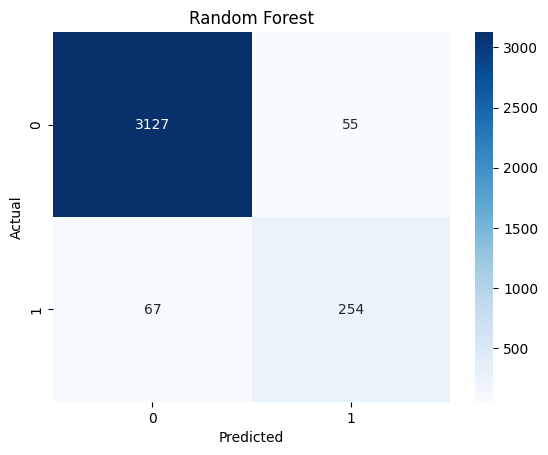

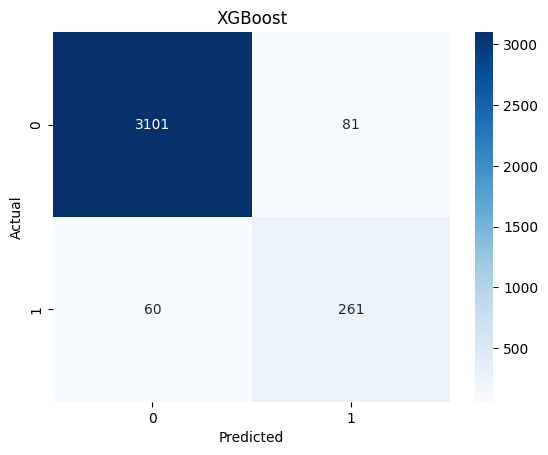

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, rf_pred, "Random Forest")
plot_cm(y_test, xgb_pred, "XGBoost")